In [1]:
import sys

import torch

import pandas as pd

import pm4py
from pm4py.visualization.petri_net import visualizer as pn_vis

from config.feature_config import FeatureConfig
from config.ga_config import GAConfig

from utils.general_utils import set_stdout_to_file, set_seed
from utils.feature_utils import df_to_sequence_array

from model.preprocessor import PreprocessorArtifacts

from model.next_event_model import ProcessLSTM
from model.model_wrapper import ModelWrapper

from ga_search.search import CounterfactualGA

from process.engine import ProcessModelConstraintEngine
from process.experimenter import ExperimentHandler

### --- Load Dataset & Models ---

In [2]:
set_seed(seed=42)

In [3]:
df = pd.read_excel(
    "../../data/hospital_billing.xlsx",
    engine="openpyxl",
    keep_default_na=False,
    dtype={
        "case:concept:name": "string",
        "concept:name": "string",
        "lifecycle:transition": "string",
        "isCancelled": "string",
        "isClosed": "string",
        "caseType": "string",
        "speciality": "string",
        "blocked": "string",
        "flagD": "string",
        "flagB": "string",
        "flagA": "string",
        "state": "string",
        "time_delta": "float32",
    }
)

df["time:timestamp"] = pd.to_datetime(df["time:timestamp"])

In [4]:
df.head(20)

,case:concept:name,time:timestamp,blocked,caseType,concept:name,flagA,flagB,flagD,isCancelled,isClosed,lifecycle:transition,speciality,state,time_delta
0,A,2012-12-16 19:33:10,False,A,NEW,False,False,True,False,True,complete,A,In progress,0.0
1,A,2013-12-15 19:00:37,NA,NA,FIN,NA,NA,NA,NA,NA,complete,NA,Closed,31447648.0
2,A,2013-12-16 03:53:38,NA,NA,RELEASE,NA,NA,NA,NA,NA,complete,NA,Released,31981.0
3,A,2013-12-17 12:56:29,NA,NA,CODE OK,NA,NA,NA,NA,NA,complete,NA,NA,118971.0
4,A,2013-12-19 03:44:31,NA,NA,BILLED,NA,NA,NA,NA,NA,complete,NA,Billed,139682.0
5,AA,2012-12-26 08:50:18,False,B,NEW,False,False,True,False,True,complete,L,In progress,0.0
6,AA,2012-12-26 08:50:59,NA,NA,CHANGE DIAGN,NA,NA,NA,NA,NA,complete,NA,In progress,41.0
7,AA,2013-02-14 21:06:33,NA,NA,FIN,NA,NA,NA,NA,NA,complete,NA,Closed,4364134.0
8,AA,2013-02-14 22:12:10,NA,NA,RELEASE,NA,NA,NA,NA,NA,complete,NA,Released,3937.0
9,AA,2013-02-18 01:44:10,NA,NA,CODE OK,NA,NA,NA,NA,NA,complete,NA,NA,271920.0


In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [6]:
feature_config = FeatureConfig.load()

In [7]:
feature_config.summary()

  activity_feature:    concept:name
  feature_order:       ['blocked', 'caseType', 'concept:name', 'flagA', 'flagB', 'flagD', 'isCancelled', 'isClosed', 'lifecycle:transition', 'speciality', 'state', 'time_delta']
--------------------------------------------------------------------------------------------------------------------------------------
Feature                        Type           Level    Vary   Range/Categories                         MAD        Source              
--------------------------------------------------------------------------------------------------------------------------------------
isCancelled                    categorical    event    yes    ['False', 'True']                        N/A        data_derived        
isClosed                       categorical    event    yes    ['False', 'True']                        N/A        data_derived        
caseType                       categorical    event    yes    ['A', 'B', 'C', ...]                     N/A     

In [8]:
preprocessor_artifacts = PreprocessorArtifacts.load()

In [9]:
model = ProcessLSTM.load()

In [10]:
model_wrapper = ModelWrapper(
    model=model,
    preprocessor_artifacts=preprocessor_artifacts,
    device=device
)

### --- Process Constraints ---

In [11]:
net, initial_marking, final_marking = pm4py.discover_petri_net_inductive(
    df,
    noise_threshold=0.5,
    case_id_key='case:concept:name',  
    activity_key='concept:name',
    timestamp_key='time:timestamp'
)

engine = ProcessModelConstraintEngine(
    petri_net=net,
    initial_marking=initial_marking,
    final_marking=final_marking
)
engine.save()

In [12]:
# engine = ProcessModelConstraintEngine.load()

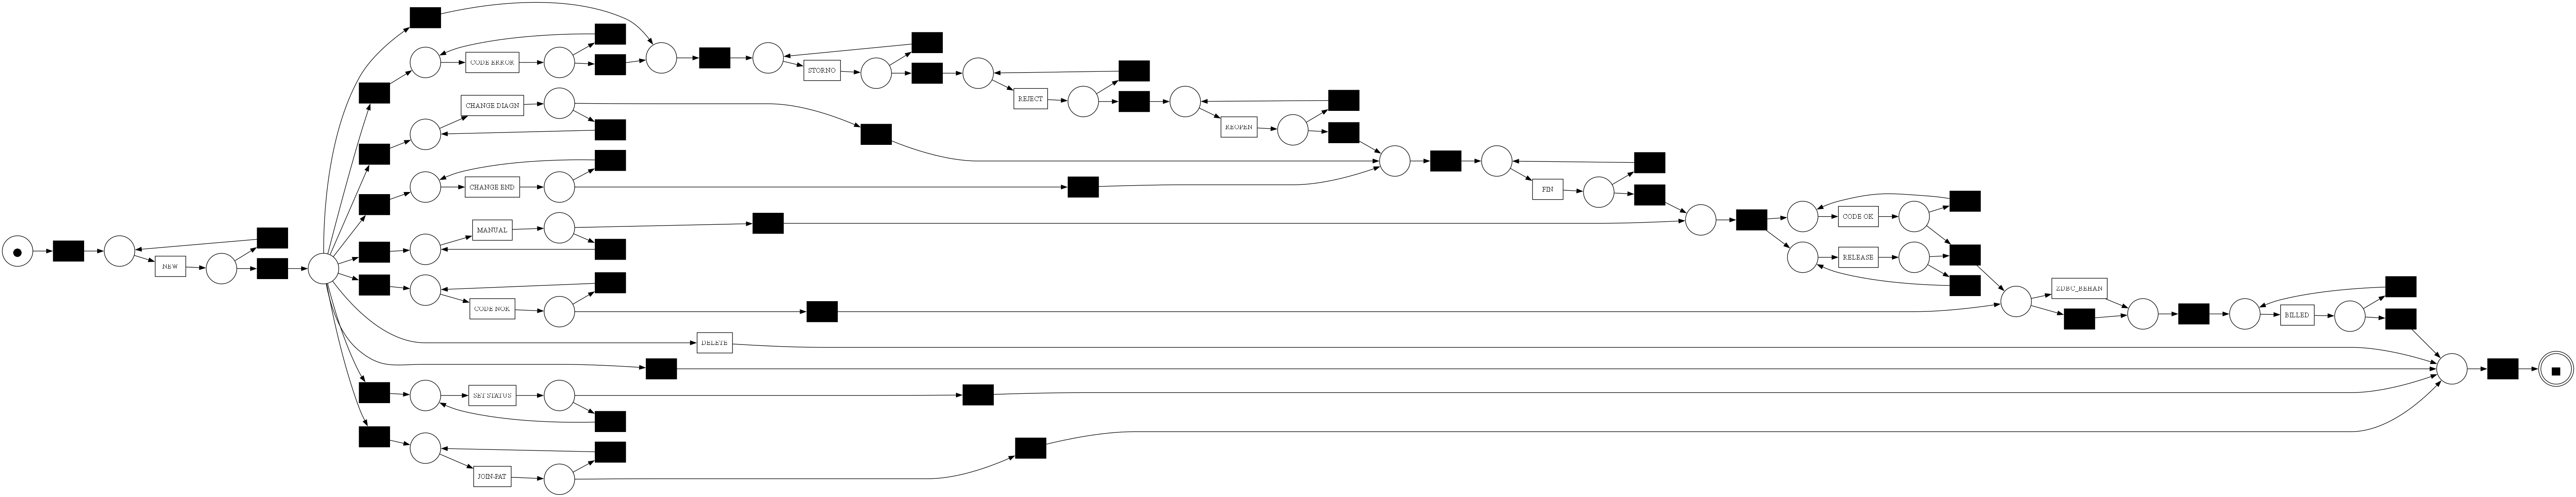

In [13]:
gviz = pn_vis.apply(
    net,
    initial_marking,
    final_marking,
)

pn_vis.view(gviz)

In [14]:
engine.parallel_sets

[{'CODE OK', 'RELEASE'}]

In [15]:
engine.branching_sets

[{'BILLED',
  'CHANGE DIAGN',
  'CHANGE END',
  'CODE ERROR',
  'CODE NOK',
  'CODE OK',
  'DELETE',
  'FIN',
  'JOIN-PAT',
  'MANUAL',
  'REJECT',
  'RELEASE',
  'REOPEN',
  'SET STATUS',
  'STORNO',
  'ZDBC_BEHAN'},
 {'CHANGE DIAGN',
  'CHANGE END',
  'CODE ERROR',
  'CODE NOK',
  'CODE OK',
  'FIN',
  'MANUAL',
  'REJECT',
  'RELEASE',
  'REOPEN',
  'STORNO'},
 {'CHANGE DIAGN',
  'CHANGE END',
  'CODE ERROR',
  'FIN',
  'MANUAL',
  'REJECT',
  'REOPEN',
  'STORNO'},
 {'CHANGE DIAGN', 'CHANGE END', 'CODE ERROR', 'REJECT', 'REOPEN', 'STORNO'}]

### --- Experiments Generation ---

In [16]:
log_file, original_stdout = set_stdout_to_file(filepath="logs/hospital_billing-cf_generated_experiments_ga_output.txt", console=False)

In [17]:
generator = ExperimentHandler(
    constraint_engine=engine,
)

In [18]:
exp_df_sin = generator.generate_experiments_from_log(
    df=df,
    case_id_field="case:concept:name",
    activity_field="concept:name",
    sort_field="time:timestamp",
    save_path="experiments/cf_generated_experiments_single_desired",
    min_desired=1,
    max_desired=1,
)

In [19]:
exp_df_mul = generator.generate_experiments_from_log(
    df=df,
    case_id_field="case:concept:name",
    activity_field="concept:name",
    sort_field="time:timestamp",
    save_path="experiments/cf_generated_experiments_multiple_desired",
    min_desired=2,
)

In [20]:
max(exp_df_sin['num_desired'])

1

In [21]:
len(exp_df_sin)

420

In [22]:
exp_df_sin.head()

,template_id,case:concept:name,trace_length,start_pos,length,num_desired,source_pattern,target_pattern,desired_positions,source_support,target_support,num_cases_for_template,experiment_type
0,0,YAWA,3,0,3,1,"(NEW, CHANGE DIAGN, FIN)","(NEW, CHANGE DIAGN, CHANGE DIAGN)",{2: {'CHANGE DIAGN'}},37953,2692,10,window_variant_mixed
1,0,VSOB,4,0,3,1,"(NEW, CHANGE DIAGN, FIN)","(NEW, CHANGE DIAGN, CHANGE DIAGN)",{2: {'CHANGE DIAGN'}},37953,2692,10,window_variant_mixed
2,0,SNUD,5,0,3,1,"(NEW, CHANGE DIAGN, FIN)","(NEW, CHANGE DIAGN, CHANGE DIAGN)",{2: {'CHANGE DIAGN'}},37953,2692,10,window_variant_mixed
3,0,SVAE,6,0,3,1,"(NEW, CHANGE DIAGN, FIN)","(NEW, CHANGE DIAGN, CHANGE DIAGN)",{2: {'CHANGE DIAGN'}},37953,2692,10,window_variant_mixed
4,0,YEVB,7,0,3,1,"(NEW, CHANGE DIAGN, FIN)","(NEW, CHANGE DIAGN, CHANGE DIAGN)",{2: {'CHANGE DIAGN'}},37953,2692,10,window_variant_mixed


In [23]:
min(exp_df_mul['num_desired'])

2

In [24]:
max(exp_df_mul['num_desired'])

9

In [25]:
len(exp_df_mul)

500

In [26]:
exp_df_mul.head()

,template_id,case:concept:name,trace_length,start_pos,length,num_desired,source_pattern,target_pattern,desired_positions,source_support,target_support,num_cases_for_template,experiment_type
0,0,YAWA,3,0,3,2,"(NEW, CHANGE DIAGN, FIN)","(NEW, FIN, RELEASE)","{1: {'FIN'}, 2: {'RELEASE'}}",37953,26491,10,window_variant_mixed
1,0,VSOB,4,0,3,2,"(NEW, CHANGE DIAGN, FIN)","(NEW, FIN, RELEASE)","{1: {'FIN'}, 2: {'RELEASE'}}",37953,26491,10,window_variant_mixed
2,0,SNUD,5,0,3,2,"(NEW, CHANGE DIAGN, FIN)","(NEW, FIN, RELEASE)","{1: {'FIN'}, 2: {'RELEASE'}}",37953,26491,10,window_variant_mixed
3,0,SVAE,6,0,3,2,"(NEW, CHANGE DIAGN, FIN)","(NEW, FIN, RELEASE)","{1: {'FIN'}, 2: {'RELEASE'}}",37953,26491,10,window_variant_mixed
4,0,YEVB,7,0,3,2,"(NEW, CHANGE DIAGN, FIN)","(NEW, FIN, RELEASE)","{1: {'FIN'}, 2: {'RELEASE'}}",37953,26491,10,window_variant_mixed


In [27]:
# exp_df_sin, metadata_sin = ExperimentHandler.load("experiments/cf_generated_experiments_single_desired")
# print("Mined using parameters:", metadata_sin["parameters"])

# exp_df_mul, metadata_mul = ExperimentHandler.load("experiments/cf_generated_experiments_multiple_desired")
# print("Mined using parameters:", metadata_mul["parameters"])

### --- Counterfactuals ---

In [28]:
ga_config = GAConfig(
    w_distance=1.0,
    w_sparsity=1.0,
    w_margin=1.0,
    w_process_violation=1.0,
)
ga_config.validate()

cf_GA = CounterfactualGA(
    ga_config=ga_config,
    feature_config=feature_config,
    model_wrapper=model_wrapper
)

In [29]:
results_sin = generator.run_experiment_df(
    cf_method=cf_GA,
    technique="GA_single_desired",
    exp_df=exp_df_sin,
    df=df,
    feature_config=feature_config,
    case_id_field="case:concept:name",
    sort_field="time:timestamp",
)

Experiments:   0%|          | 0/420 [00:00<?, ?case/s]

In [30]:
results_sin

,template_id,case:concept:name,trace_length,num_desired,num_flexible,DISTANCE,CONT_DISTANCE,CAT_DISTANCE,SPARSITY,PROCESS_VIOLATION,...,best_cf_fitness,best_cf_process_violation,best_cf_distance,best_cf_cat_distance,best_cf_cont_distance,best_cf_sparsity,best_cf_margin_loss,best_cf_margin_loss_na,best_cf_margin_loss_flipped,best_cf_margin_loss_na_flipped
0,0,YAWA,3,1,0,0.556097,0.651083,0.461111,0.5100,0.000000,...,0.395444,0.000000,0.195444,0.166667,0.224222,0.20,0.0,0.000000,0.0,0.000000
1,0,VSOB,4,1,0,0.486921,0.473842,0.500000,0.5375,0.136364,...,0.438905,0.000000,0.138905,0.277778,0.000032,0.30,0.0,0.000000,0.0,0.000000
2,0,SNUD,5,1,0,0.603185,0.806369,0.400000,0.4575,0.269231,...,0.592747,0.153846,0.138901,0.277778,0.000024,0.30,0.0,0.000000,0.0,0.000000
3,0,SVAE,6,1,2,0.584947,0.656004,0.513889,0.5575,0.266667,...,0.783346,0.266667,0.166680,0.333333,0.000026,0.35,0.0,0.000000,0.0,0.000000
4,0,YEVB,7,1,0,0.537665,0.611440,0.463889,0.5050,0.235294,...,0.597864,0.235294,0.112570,0.222222,0.002918,0.25,0.0,0.000000,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
365,41,RPR,11,1,4,0.557157,0.541536,0.572778,0.5995,0.540000,...,0.443367,0.000000,0.283367,0.077778,0.488956,0.16,0.0,0.968186,0.0,1.000000
366,41,UHJB,11,1,4,0.621054,0.578219,0.663889,0.6900,0.440000,...,0.569719,0.000000,0.299719,0.222222,0.377217,0.27,0.0,0.000000,0.0,0.000000
367,41,GNDB,11,1,4,0.514347,0.476472,0.552222,0.5880,0.552000,...,0.247497,0.000000,0.157497,0.000000,0.314993,0.09,0.0,0.729715,0.0,0.999999
368,41,CDMA,12,1,4,0.436916,0.381054,0.492778,0.5000,0.437037,...,0.187611,0.074074,0.063537,0.044444,0.082629,0.05,0.0,0.868195,0.0,1.000000


In [31]:
results_mul = generator.run_experiment_df(
    cf_method=cf_GA,
    technique="GA_multiple_desired",
    exp_df=exp_df_mul,
    df=df,
    feature_config=feature_config,
    case_id_field="case:concept:name",
    sort_field="time:timestamp",
)

Experiments:   0%|          | 0/500 [00:00<?, ?case/s]

In [32]:
results_mul

,template_id,case:concept:name,trace_length,num_desired,num_flexible,DISTANCE,CONT_DISTANCE,CAT_DISTANCE,SPARSITY,PROCESS_VIOLATION,...,best_cf_fitness,best_cf_process_violation,best_cf_distance,best_cf_cat_distance,best_cf_cont_distance,best_cf_sparsity,best_cf_margin_loss,best_cf_margin_loss_na,best_cf_margin_loss_flipped,best_cf_margin_loss_na_flipped
0,0,YAWA,3,2,0,0.489370,0.712074,0.266667,0.335000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.0,0.000000,0.0,0.00
1,0,VSOB,4,2,0,0.516902,0.722693,0.311111,0.375000,0.142857,...,0.298413,0.142857,0.055556,0.111111,0.000000,0.1000,0.0,0.475995,0.0,0.50
2,0,SNUD,5,2,0,0.561580,0.728717,0.394444,0.450000,0.250000,...,0.561111,0.250000,0.111111,0.222222,0.000000,0.2000,0.0,0.473853,0.0,0.50
3,0,SVAE,6,2,2,0.420471,0.568720,0.272222,0.340000,0.227778,...,0.377778,0.222222,0.055556,0.111111,0.000000,0.1000,0.0,0.482139,0.0,0.50
4,0,YEVB,7,2,0,0.290769,0.353760,0.227778,0.255000,0.300000,...,0.455556,0.300000,0.055556,0.111111,0.000000,0.1000,0.0,0.475040,0.0,0.50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
468,49,MPV,17,4,4,0.655967,0.665406,0.646528,0.681250,0.356522,...,0.449848,0.086957,0.262892,0.013889,0.511894,0.1000,0.0,0.731604,0.0,0.75
469,49,XJY,18,4,2,0.495580,0.460605,0.530556,0.547500,0.376042,...,0.444444,0.250000,0.069444,0.138889,0.000000,0.1250,0.0,0.732487,0.0,0.75
470,49,YXWC,21,4,2,0.596991,0.596760,0.597222,0.635000,0.501852,...,0.664099,0.333333,0.218266,0.027778,0.408754,0.1125,0.0,0.727433,0.0,0.75
471,49,ZGLB,22,4,2,0.512629,0.468314,0.556944,0.565625,0.507143,...,0.568254,0.357143,0.111111,0.097222,0.125000,0.1000,0.0,0.733884,0.0,0.75


### --- Cleanup ---

In [33]:
sys.stdout = original_stdout
log_file.close()